In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import colorsys
import pandas as pd
from pathlib import Path
from hypo_sleep import Session
import spikeinterface.full as si
from scipy import signal, stats
import xarray as xr
import statsmodels.api as sm
from functools import partial

In [2]:
SMALL_SIZE = 20
MEDIUM_SIZE = 24
BIGGER_SIZE = 28
BIGGEST_SIZE = 38

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=BIGGER_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=MEDIUM_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=MEDIUM_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)
plt.rc("figure", labelsize=BIGGEST_SIZE)

In [3]:
data_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
full_dict = {
    "HYDO03": {
        "dates": ["2025-02-18_09-19-26", "2025-02-20_08-58-57"],
        "configs": ["2783", "97fa"],  # ["f1b1", "5fdd"],
    },
    "HYDO04": {
        "dates": ["2025-02-24_09-00-29", "2025-02-26_09-05-08"],
        "configs": ["07b2", "07db"],
    },
}
depth_ordered_chs = np.array(
    [
        "24",
        "23",
        "25",
        "22",
        "8",
        "7",
        "9",
        "6",
        "15",
        "0",
        "14",
        "1",
        "26",
        "21",
        "27",
        "20",
        "10",
        "5",
        "28",
        "19",
        "11",
        "4",
        "29",
        "18",
        "12",
        "3",
        "30",
        "17",
        "13",
        "2",
        "31",
        "16",
    ]
)
top = depth_ordered_chs[: depth_ordered_chs.size // 2]
bottom = depth_ordered_chs[depth_ordered_chs.size // 2 :]

## Event PSDs

In [4]:
triggers = ["spi-peak", "so-peak", "nrem-null"]
data_dict = {
    date: {trigger: {} for trigger in triggers}
    for date in [
        date for meta_dict in full_dict.values() for date in meta_dict["dates"]
    ]
}
trigger_ch = "39"
print("loading spectra")
for animal, meta_dict in full_dict.items():
    for date, config_id in zip(meta_dict["dates"], meta_dict["configs"]):
        tmp_output_path = Path(
            "/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/",
            animal,
            date,
            config_id,
            "spectra",
        )
        for trigger, tmp_dict in data_dict[date].items():
            for region in ["ctx", "hyp"]:
                print(animal, date, trigger, region)
                load_path = Path(
                    tmp_output_path,
                    f"spectra_{trigger_ch}_{trigger}_meth-mtm_psd_{region}_{config_id}.nc",
                )
                if load_path.exists():
                    tmp_da = xr.load_dataarray(load_path, engine="h5netcdf")
                    tmp_dict[region] = tmp_da
                else:
                    tmp_dict[region] = None
                    print(f"File not found: {load_path}")
                    continue

loading spectra
HYDO03 2025-02-18_09-19-26 spi-peak ctx
HYDO03 2025-02-18_09-19-26 spi-peak hyp
HYDO03 2025-02-18_09-19-26 so-peak ctx
HYDO03 2025-02-18_09-19-26 so-peak hyp
HYDO03 2025-02-18_09-19-26 nrem-null ctx
HYDO03 2025-02-18_09-19-26 nrem-null hyp
HYDO03 2025-02-20_08-58-57 spi-peak ctx
HYDO03 2025-02-20_08-58-57 spi-peak hyp
HYDO03 2025-02-20_08-58-57 so-peak ctx
HYDO03 2025-02-20_08-58-57 so-peak hyp
HYDO03 2025-02-20_08-58-57 nrem-null ctx
HYDO03 2025-02-20_08-58-57 nrem-null hyp
HYDO04 2025-02-24_09-00-29 spi-peak ctx
HYDO04 2025-02-24_09-00-29 spi-peak hyp
HYDO04 2025-02-24_09-00-29 so-peak ctx
HYDO04 2025-02-24_09-00-29 so-peak hyp
HYDO04 2025-02-24_09-00-29 nrem-null ctx
HYDO04 2025-02-24_09-00-29 nrem-null hyp
HYDO04 2025-02-26_09-05-08 spi-peak ctx
HYDO04 2025-02-26_09-05-08 spi-peak hyp
HYDO04 2025-02-26_09-05-08 so-peak ctx
HYDO04 2025-02-26_09-05-08 so-peak hyp
HYDO04 2025-02-26_09-05-08 nrem-null ctx
HYDO04 2025-02-26_09-05-08 nrem-null hyp


In [5]:
animal_xr_dict = {
    animal: {
        trigger: {region: None for region in ["ctx", "hyp"]}
        for trigger in ["so-peak", "spi-peak", "nrem-null"]
    }
    for animal in full_dict.keys()
}
for animal, animal_meta in full_dict.items():
    for trigger in ["so-peak", "spi-peak", "nrem-null"]:
        for region in ["ctx", "hyp"]:
            animal_xr_dict[animal][trigger][region] = [
                data_dict[date][trigger][region] for date in animal_meta["dates"]
            ]

In [6]:
region_xr_dict = {}
for region in ["ctx", "hyp"]:
    so_xr_full = xr.concat(
        [
            val.mean("channel")
            for ani_dict in animal_xr_dict.values()
            for val in ani_dict["so-peak"][region]
        ],
        dim="trial",
    )
    so_xr_full = so_xr_full.assign_coords(trial=range(so_xr_full.sizes["trial"]))
    spi_xr_full = xr.concat(
        [
            val.mean("channel")
            for ani_dict in animal_xr_dict.values()
            for val in ani_dict["spi-peak"][region]
        ],
        dim="trial",
    )
    spi_xr_full = spi_xr_full.assign_coords(trial=range(spi_xr_full.sizes["trial"]))
    null_xr_full = xr.concat(
        [
            val.mean("channel")
            for ani_dict in animal_xr_dict.values()
            for val in ani_dict["nrem-null"][region]
        ],
        dim="trial",
    )
    null_xr_full = null_xr_full.assign_coords(trial=range(null_xr_full.sizes["trial"]))
    region_xr_dict[region] = {
        "spi-peak": spi_xr_full,
        "so-peak": so_xr_full,
        "nrem-null": null_xr_full,
    }

In [7]:
import matplotlib as mpl
from matplotlib.patches import Patch

sig_code_dict = {}
cmap = mpl.colormaps.get_cmap("Dark2")
tmp_colors = [cmap(i) for i in range(8)]
# new_code = {
#     1: {"label": "so_spi", "color": tmp_colors[0]},
#     3: {"label": "spi_null", "color": tmp_colors[1]},
#     4: {"label": "so_spi + spi_null", "color": tmp_colors[2]},
#     5: {"label": "so_null", "color": tmp_colors[3]},
#     6: {"label": "so_spi + so_null", "color": tmp_colors[4]},
#     8: {"label": "spi_null + so_null", "color": tmp_colors[5]},
#     9: {"label": "all_sig", "color": tmp_colors[6]},
# }
new_code = {
    1: {"label": "so_spi", "color": tmp_colors[0]},
    2: {"label": "spi_null", "color": tmp_colors[1]},
    3: {"label": "so_null", "color": tmp_colors[2]},
}
for region, reg_dict in region_xr_dict.items():
    sig_code_dict[region] = {}
    # so_xr = xr.concat(
    #     animal_xr_dict["HYDO04"]["so-peak"][region], dim="epoch", join="inner"
    # )
    # spi_xr = xr.concat(
    #     animal_xr_dict["HYDO04"]["spi-peak"][region], dim="epoch", join="inner"
    # )
    # null_xr = xr.concat(
    #     animal_xr_dict["HYDO04"]["nrem-null"][region], dim="epoch", join="inner"
    # )
    so_spi = stats.ttest_ind(reg_dict["so-peak"], reg_dict["spi-peak"])
    spi_null = stats.ttest_ind(reg_dict["spi-peak"], reg_dict["nrem-null"])
    so_null = stats.ttest_ind(reg_dict["so-peak"], reg_dict["nrem-null"])
    pvals = np.stack([so_spi.pvalue, spi_null.pvalue, so_null.pvalue])
    reject = []
    corr_pvals = []
    for tmp_pvals in pvals.T:
        tmp_reject, tmp_corr, _, _ = sm.stats.multipletests(
            tmp_pvals.flatten(), method="bonferroni"
        )
        reject.append(tmp_reject)
        corr_pvals.append(tmp_corr)
    corr_pvals = np.stack(corr_pvals).T  # .reshape(pvals.shape)
    reject = np.stack(reject).T  # .reshape(pvals.shape)
    so_spi_spi_null = np.logical_and(reject[0], reject[1])
    so_spi_so_null = np.logical_and(reject[0], reject[2])
    spi_null_so_null = np.logical_and(reject[1], reject[2])
    all_not_reject = np.logical_and.reduce((reject[0], reject[1], reject[2]))
    single_codes = np.zeros_like(reject, dtype=np.float16)
    code_vals = np.logspace(3.5, 3.7, 3)
    single_codes[0, reject[0]] = code_vals[0]
    single_codes[1, reject[1]] = code_vals[1]
    single_codes[2, reject[2]] = code_vals[2]
    # sig_codes = reject[0] * 1 + reject[1] * 3 + reject[2] * 5
    sig_code_dict[region]["codes"] = single_codes
    # color_codes = np.zeros(shape=(sig_codes.size, 4))
    # for code, vals in new_code.items():
    #     code_inds = np.where(sig_codes == code)[0]
    #     color_codes[code_inds, :] = vals["color"]
    # sig_code_dict[region]["colors"] = color_codes
    # color_codes = np.zeros(shape=(sig_codes.size, 4))
    # for code, vals in new_code.items():
    #     code_inds = np.where(sig_codes == code)[0]
    #     color_codes[code_inds, :] = vals["color"]
    # sig_code_dict[region]["colors"] = color_codes

<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_137896/4253718160.py:47: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel("Power $[\log(\\frac{\mu V^{2}}{Hz})]$", fontsize=36)


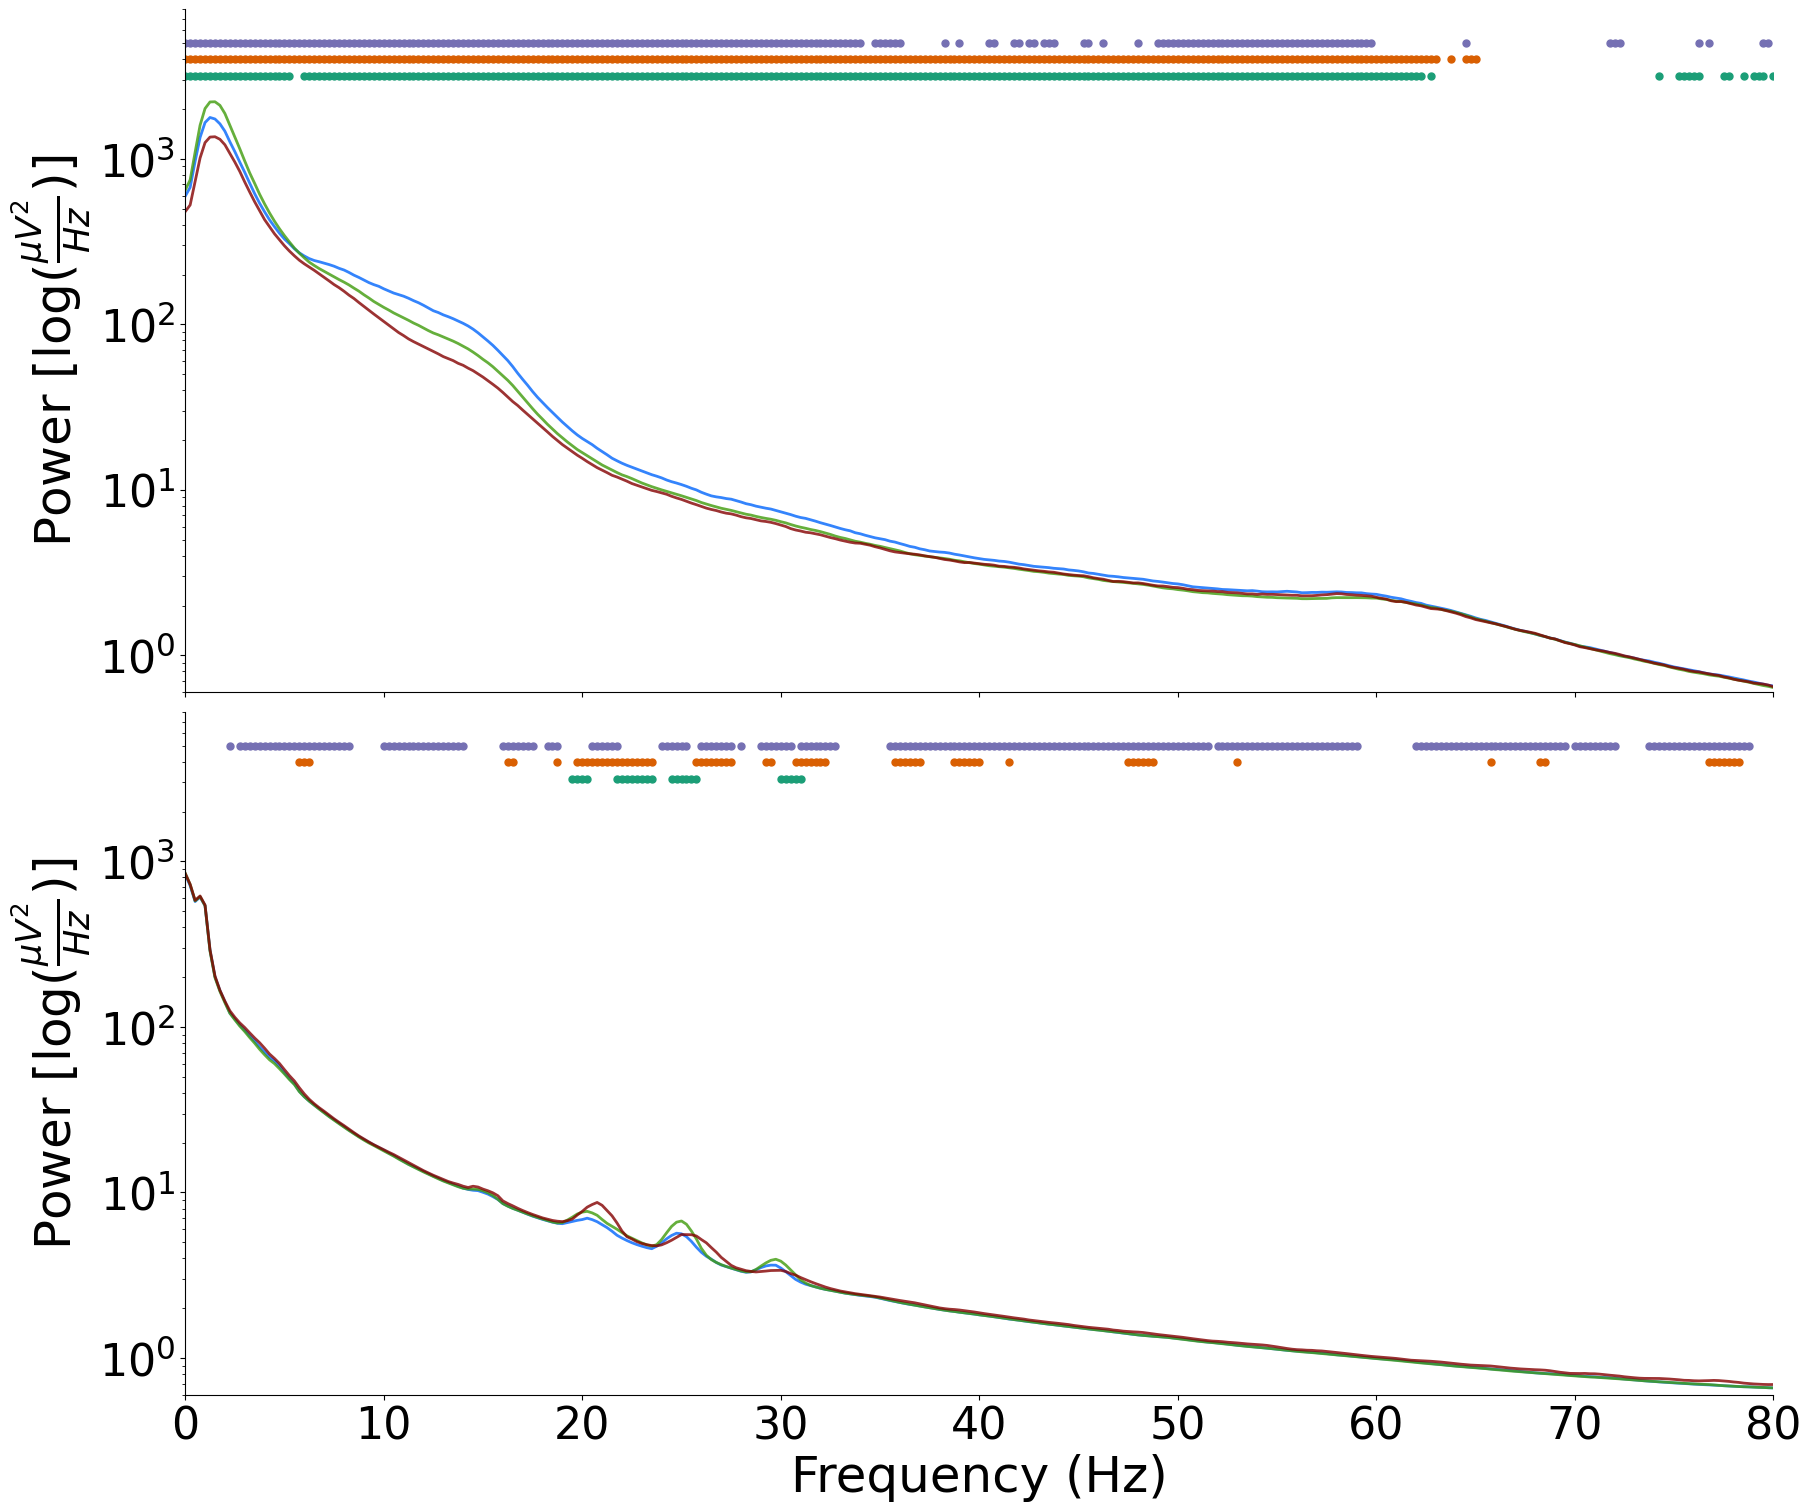

In [26]:
color_dict = {"spi-peak": "#0165fc", "so-peak": "#3f9b0b", "nrem-null": "#840000"}
fig, axs = plt.subplots(
    nrows=2, figsize=(18, 15), sharex=True, sharey=True, constrained_layout=True
)
freq_slice = slice(0, 80)
all_handles = [
    Patch(color=val["color"], label=val["label"])
    for ind, (code, val) in enumerate(new_code.items())
]
for ax, (region, reg_dict) in zip(axs.ravel(), region_xr_dict.items()):
    # tmp_trials = trials if trigger in ["spi-peak", "so-peak"] else np.arange(28)
    ind = 0
    for trigger, trig_data in reg_dict.items():
        trig_label = (
            trigger.split("-")[0] if trigger in ["spi-peak", "so-peak"] else "null"
        )
        indices = trig_data.get_index("freq").get_indexer_for(
            trig_data.sel(freq=freq_slice).freq.values
        )
        # channels = ["39"] if region == "ctx" else tmp.channel.values
        # for channel in channels:
        plot_data_mean = trig_data.sel(freq=freq_slice).mean(dim=("trial"))
        plot_data_std = trig_data.sel(freq=freq_slice).std(dim=("trial"))
        ax.plot(
            plot_data_mean.freq.values,
            plot_data_mean,
            label=f"{trig_label}",
            color=color_dict[trigger],
            lw=2,
            alpha=0.8,
        )
    for i in range(3):
        ax.scatter(
            trig_data.freq.values[indices],
            sig_code_dict[region]["codes"][i, indices],
            color=new_code[i + 1]["color"],
            s=100,
            marker=".",
        )
        # ax.fill_between(
        #     plot_data_mean.freq.values,
        #     plot_data_mean - plot_data_std,
        #     plot_data_mean + plot_data_std,
        #     alpha=0.4,
        # )
    # ax.set_ylabel(region)
    ax.set_ylabel("Power $[\log(\\frac{\mu V^{2}}{Hz})]$", fontsize=36)

# auto_handles, _ = axs[1].get_legend_handles_labels()
# all_handles.extend(auto_handles)
# leg = axs[1].legend(
#     handles=all_handles, handlelength=1, handleheight=0.5, ncol=2, loc="center right"
# )
# for line in leg.get_lines():
#     line.set_linewidth(3)
# ind += 1
for ax in axs.ravel():
    ax.set_yscale("log")
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_tick_params(labelsize=32)
    ax.xaxis.set_tick_params(labelsize=32)
axs[-1].set_xlabel("Frequency (Hz)", fontsize=36)
axs[-1].set_xlim([0, 80])
axs[-1].set_ylim([0.6, 8000])
fig.savefig(
    Path("/gpfs01/born/animal/DanielG/hypo_sleep/figures", "event_psd_stats.png"),
    dpi=500,
    facecolor="white",
    transparent=False,
    bbox_inches="tight",
)
# leg = axs[-1].legend()

Text(0.5, 0, 'Frequency (Hz)')

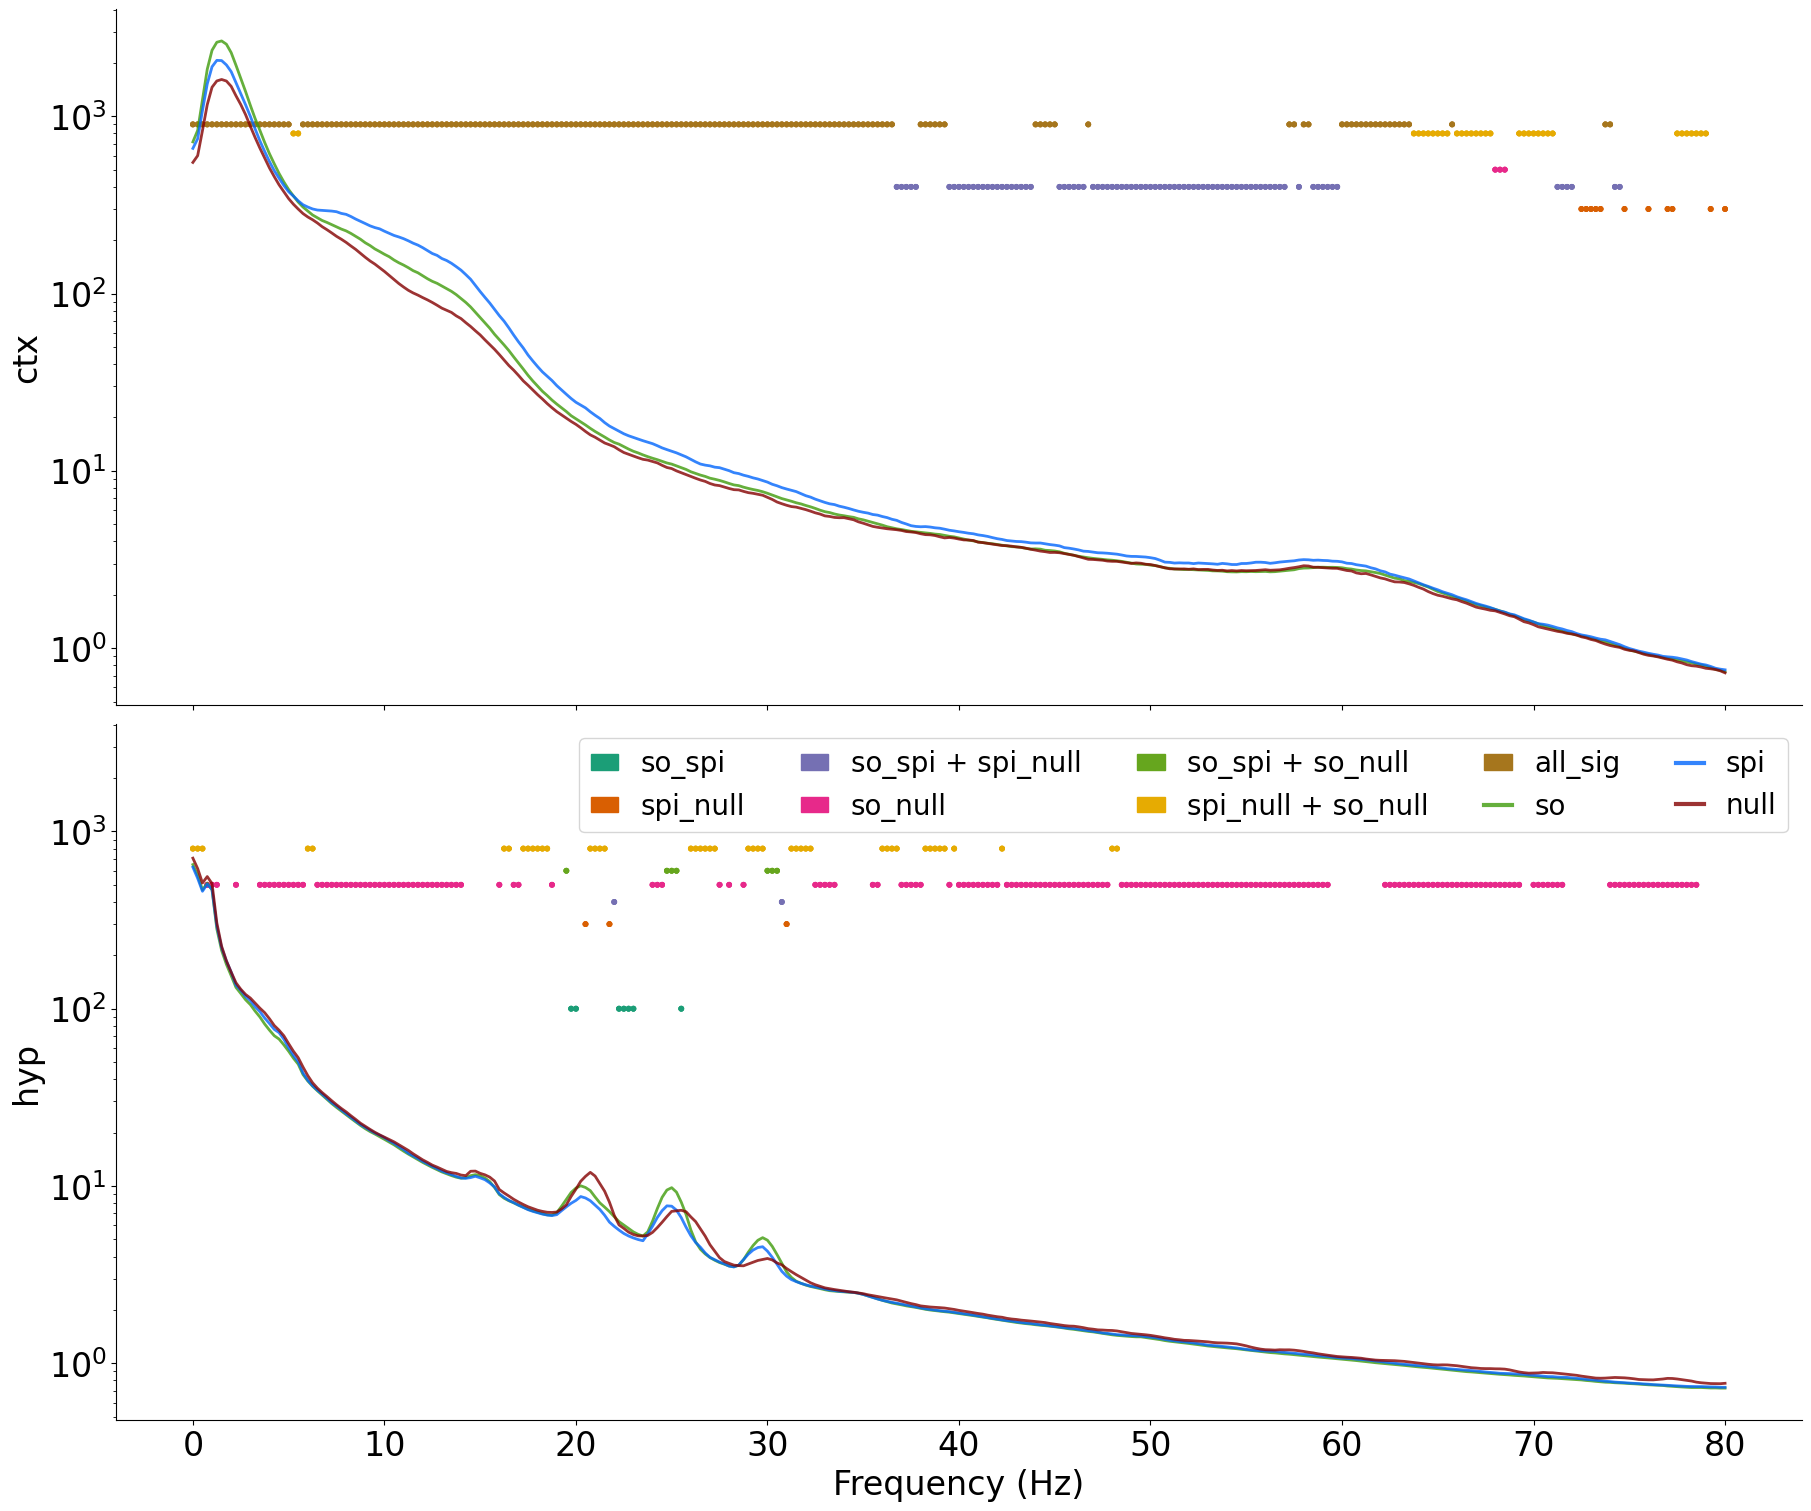

In [ ]:
color_dict = {"spi-peak": "#0165fc", "so-peak": "#3f9b0b", "nrem-null": "#840000"}
fig, axs = plt.subplots(
    nrows=2, figsize=(18, 15), sharex=True, sharey=True, constrained_layout=True
)
freq_slice = slice(0, 80)
all_handles = [
    Patch(color=tmp_colors[ind], label=val["label"])
    for ind, (code, val) in enumerate(new_code.items())
]
for trigger, trig_data in animal_xr_dict["HYDO04"].items():
    # tmp_trials = trials if trigger in ["spi-peak", "so-peak"] else np.arange(28)
    ind = 0
    for ax, (region, data) in zip(axs.ravel(), trig_data.items()):
        tmp = xr.concat(data, dim="epoch")
        trig_label = (
            trigger.split("-")[0] if trigger in ["spi-peak", "so-peak"] else "null"
        )
        indices = tmp.get_index("freq").get_indexer_for(
            tmp.sel(freq=freq_slice).freq.values
        )
        # channels = ["39"] if region == "ctx" else tmp.channel.values
        # for channel in channels:
        plot_data_mean = tmp.sel(freq=freq_slice).mean(
            dim=("epoch", "channel", "trial")
        )
        plot_data_std = tmp.sel(freq=freq_slice).std(dim=("epoch", "channel", "trial"))
        ax.plot(
            plot_data_mean.freq.values,
            plot_data_mean,
            label=f"{trig_label}",
            c=color_dict[trigger],
            lw=2,
            alpha=0.8,
        )
        for i in range(3):
            ax.scatter(
                state_data.freq.values[indices],
                sig_code_state_dict[region]["codes"][i, indices],
                color=new_state_code[i + 1]["color"],
                s=40,
                marker=".",
            )
        # ax.scatter(
        #     tmp.freq.values[indices],
        #     sig_code_dict[region]["codes"][indices] * 100,
        #     c=sig_code_dict[region]["colors"][indices],
        #     s=40,
        #     marker=".",
        # )
        # ax.fill_between(
        #     plot_data_mean.freq.values,
        #     plot_data_mean - plot_data_std,
        #     plot_data_mean + plot_data_std,
        #     alpha=0.4,
        # )
        ax.set_ylabel(region)

auto_handles, _ = axs[1].get_legend_handles_labels()
all_handles.extend(auto_handles)
leg = axs[1].legend(handles=all_handles, handlelength=1, handleheight=0.5, ncol=5)
for line in leg.get_lines():
    line.set_linewidth(3)
# ind += 1
for ax in axs.ravel():
    ax.set_yscale("log")
    ax.spines[["top", "right"]].set_visible(False)
axs[-1].set_xlabel("Frequency (Hz)")
# leg = axs[-1].legend()

## State PSDs

In [19]:
triggers = ["nrem-all", "rem-all", "wake-all"]
state_data_dict = {
    date: {trigger: {} for trigger in triggers}
    for date in [
        date for meta_dict in full_dict.values() for date in meta_dict["dates"]
    ]
}
print("loading spectra")
for animal, meta_dict in full_dict.items():
    for date, config_id in zip(meta_dict["dates"], meta_dict["configs"]):
        tmp_output_path = Path(
            "/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/",
            animal,
            date,
            config_id,
            "spectra",
        )
        for trigger, tmp_dict in state_data_dict[date].items():
            for region in ["ctx", "hyp"]:
                print(animal, date, trigger, region)
                load_path = Path(
                    tmp_output_path,
                    f"spectra_{trigger}_meth-mtm_psd_{region}_{config_id}.nc",
                )
                if load_path.exists():
                    tmp_da = xr.load_dataarray(load_path, engine="h5netcdf")
                    tmp_dict[region] = tmp_da
                else:
                    tmp_dict[region] = None
                    print(f"File not found: {load_path}")
                    continue

loading spectra
HYDO03 2025-02-18_09-19-26 nrem-all ctx
HYDO03 2025-02-18_09-19-26 nrem-all hyp
HYDO03 2025-02-18_09-19-26 rem-all ctx
HYDO03 2025-02-18_09-19-26 rem-all hyp
HYDO03 2025-02-18_09-19-26 wake-all ctx
HYDO03 2025-02-18_09-19-26 wake-all hyp
HYDO03 2025-02-20_08-58-57 nrem-all ctx
HYDO03 2025-02-20_08-58-57 nrem-all hyp
HYDO03 2025-02-20_08-58-57 rem-all ctx
HYDO03 2025-02-20_08-58-57 rem-all hyp
HYDO03 2025-02-20_08-58-57 wake-all ctx
HYDO03 2025-02-20_08-58-57 wake-all hyp
HYDO04 2025-02-24_09-00-29 nrem-all ctx
HYDO04 2025-02-24_09-00-29 nrem-all hyp
HYDO04 2025-02-24_09-00-29 rem-all ctx
HYDO04 2025-02-24_09-00-29 rem-all hyp
HYDO04 2025-02-24_09-00-29 wake-all ctx
HYDO04 2025-02-24_09-00-29 wake-all hyp
HYDO04 2025-02-26_09-05-08 nrem-all ctx
HYDO04 2025-02-26_09-05-08 nrem-all hyp
HYDO04 2025-02-26_09-05-08 rem-all ctx
HYDO04 2025-02-26_09-05-08 rem-all hyp
HYDO04 2025-02-26_09-05-08 wake-all ctx
HYDO04 2025-02-26_09-05-08 wake-all hyp


In [20]:
animal_state_dict = {
    animal: {
        trigger: {region: None for region in ["ctx", "hyp"]}
        for trigger in ["nrem-all", "rem-all", "wake-all"]
    }
    for animal in full_dict.keys()
}
for animal, animal_meta in full_dict.items():
    for trigger in ["nrem-all", "rem-all", "wake-all"]:
        for region in ["ctx", "hyp"]:
            animal_state_dict[animal][trigger][region] = [
                state_data_dict[date][trigger][region] for date in animal_meta["dates"]
            ]

In [21]:
region_state_dict = {}
for region in ["ctx", "hyp"]:
    nrem_xr_full = xr.concat(
        [
            val.mean("channel")
            for ani_dict in animal_state_dict.values()
            for val in ani_dict["nrem-all"][region]
        ],
        dim="trial",
    )
    nrem_xr_full = nrem_xr_full.assign_coords(trial=range(nrem_xr_full.sizes["trial"]))
    rem_xr_full = xr.concat(
        [
            val.mean("channel")
            for ani_dict in animal_state_dict.values()
            for val in ani_dict["rem-all"][region]
        ],
        dim="trial",
    )
    rem_xr_full = rem_xr_full.assign_coords(trial=range(rem_xr_full.sizes["trial"]))
    wake_xr_full = xr.concat(
        [
            val.mean("channel")
            for ani_dict in animal_state_dict.values()
            for val in ani_dict["wake-all"][region]
        ],
        dim="trial",
    )
    wake_xr_full = wake_xr_full.assign_coords(trial=range(wake_xr_full.sizes["trial"]))
    region_state_dict[region] = {
        "nrem-all": nrem_xr_full,
        "rem-all": rem_xr_full,
        "wake-all": wake_xr_full,
    }

In [22]:
import matplotlib as mpl
from matplotlib.patches import Patch

sig_code_state_dict = {}
cmap = mpl.colormaps.get_cmap("Dark2")
tmp_colors = [cmap(i) for i in range(8)]
# new_code = {
#     1: {"label": "so_spi", "color": tmp_colors[0]},
#     3: {"label": "spi_null", "color": tmp_colors[1]},
#     4: {"label": "so_spi + spi_null", "color": tmp_colors[2]},
#     5: {"label": "so_null", "color": tmp_colors[3]},
#     6: {"label": "so_spi + so_null", "color": tmp_colors[4]},
#     8: {"label": "spi_null + so_null", "color": tmp_colors[5]},
#     9: {"label": "all_sig", "color": tmp_colors[6]},
# }
new_state_code = {
    1: {"label": "nrem_rem", "color": tmp_colors[0]},
    2: {"label": "nrem_wake", "color": tmp_colors[1]},
    3: {"label": "rem_wake", "color": tmp_colors[2]},
}
for region, reg_dict in region_state_dict.items():
    sig_code_state_dict[region] = {}
    # so_xr = xr.concat(
    #     animal_xr_dict["HYDO04"]["so-peak"][region], dim="epoch", join="inner"
    # )
    # spi_xr = xr.concat(
    #     animal_xr_dict["HYDO04"]["spi-peak"][region], dim="epoch", join="inner"
    # )
    # null_xr = xr.concat(
    #     animal_xr_dict["HYDO04"]["nrem-null"][region], dim="epoch", join="inner"
    # )
    nrem_rem = stats.ttest_ind(reg_dict["nrem-all"], reg_dict["rem-all"])
    nrem_wake = stats.ttest_ind(reg_dict["nrem-all"], reg_dict["wake-all"])
    rem_wake = stats.ttest_ind(reg_dict["rem-all"], reg_dict["wake-all"])
    pvals = np.stack([nrem_rem.pvalue, nrem_wake.pvalue, rem_wake.pvalue])
    reject = []
    corr_pvals = []
    for tmp_pvals in pvals.T:
        tmp_reject, tmp_corr, _, _ = sm.stats.multipletests(
            tmp_pvals.flatten(), method="bonferroni"
        )
        reject.append(tmp_reject)
        corr_pvals.append(tmp_corr)
    corr_pvals = np.stack(corr_pvals).T  # .reshape(pvals.shape)
    reject = np.stack(reject).T  # .reshape(pvals.shape)
    single_codes = np.zeros_like(reject, dtype=np.float16)
    code_vals = np.logspace(3.6, 3.8, 3)
    single_codes[0, reject[0]] = code_vals[0]
    single_codes[1, reject[1]] = code_vals[1]
    single_codes[2, reject[2]] = code_vals[2]
    sig_code_state_dict[region]["codes"] = single_codes

<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_137896/423129664.py:44: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel("Power $[\log(\\frac{\mu V^{2}}{Hz})]$", fontsize=36)


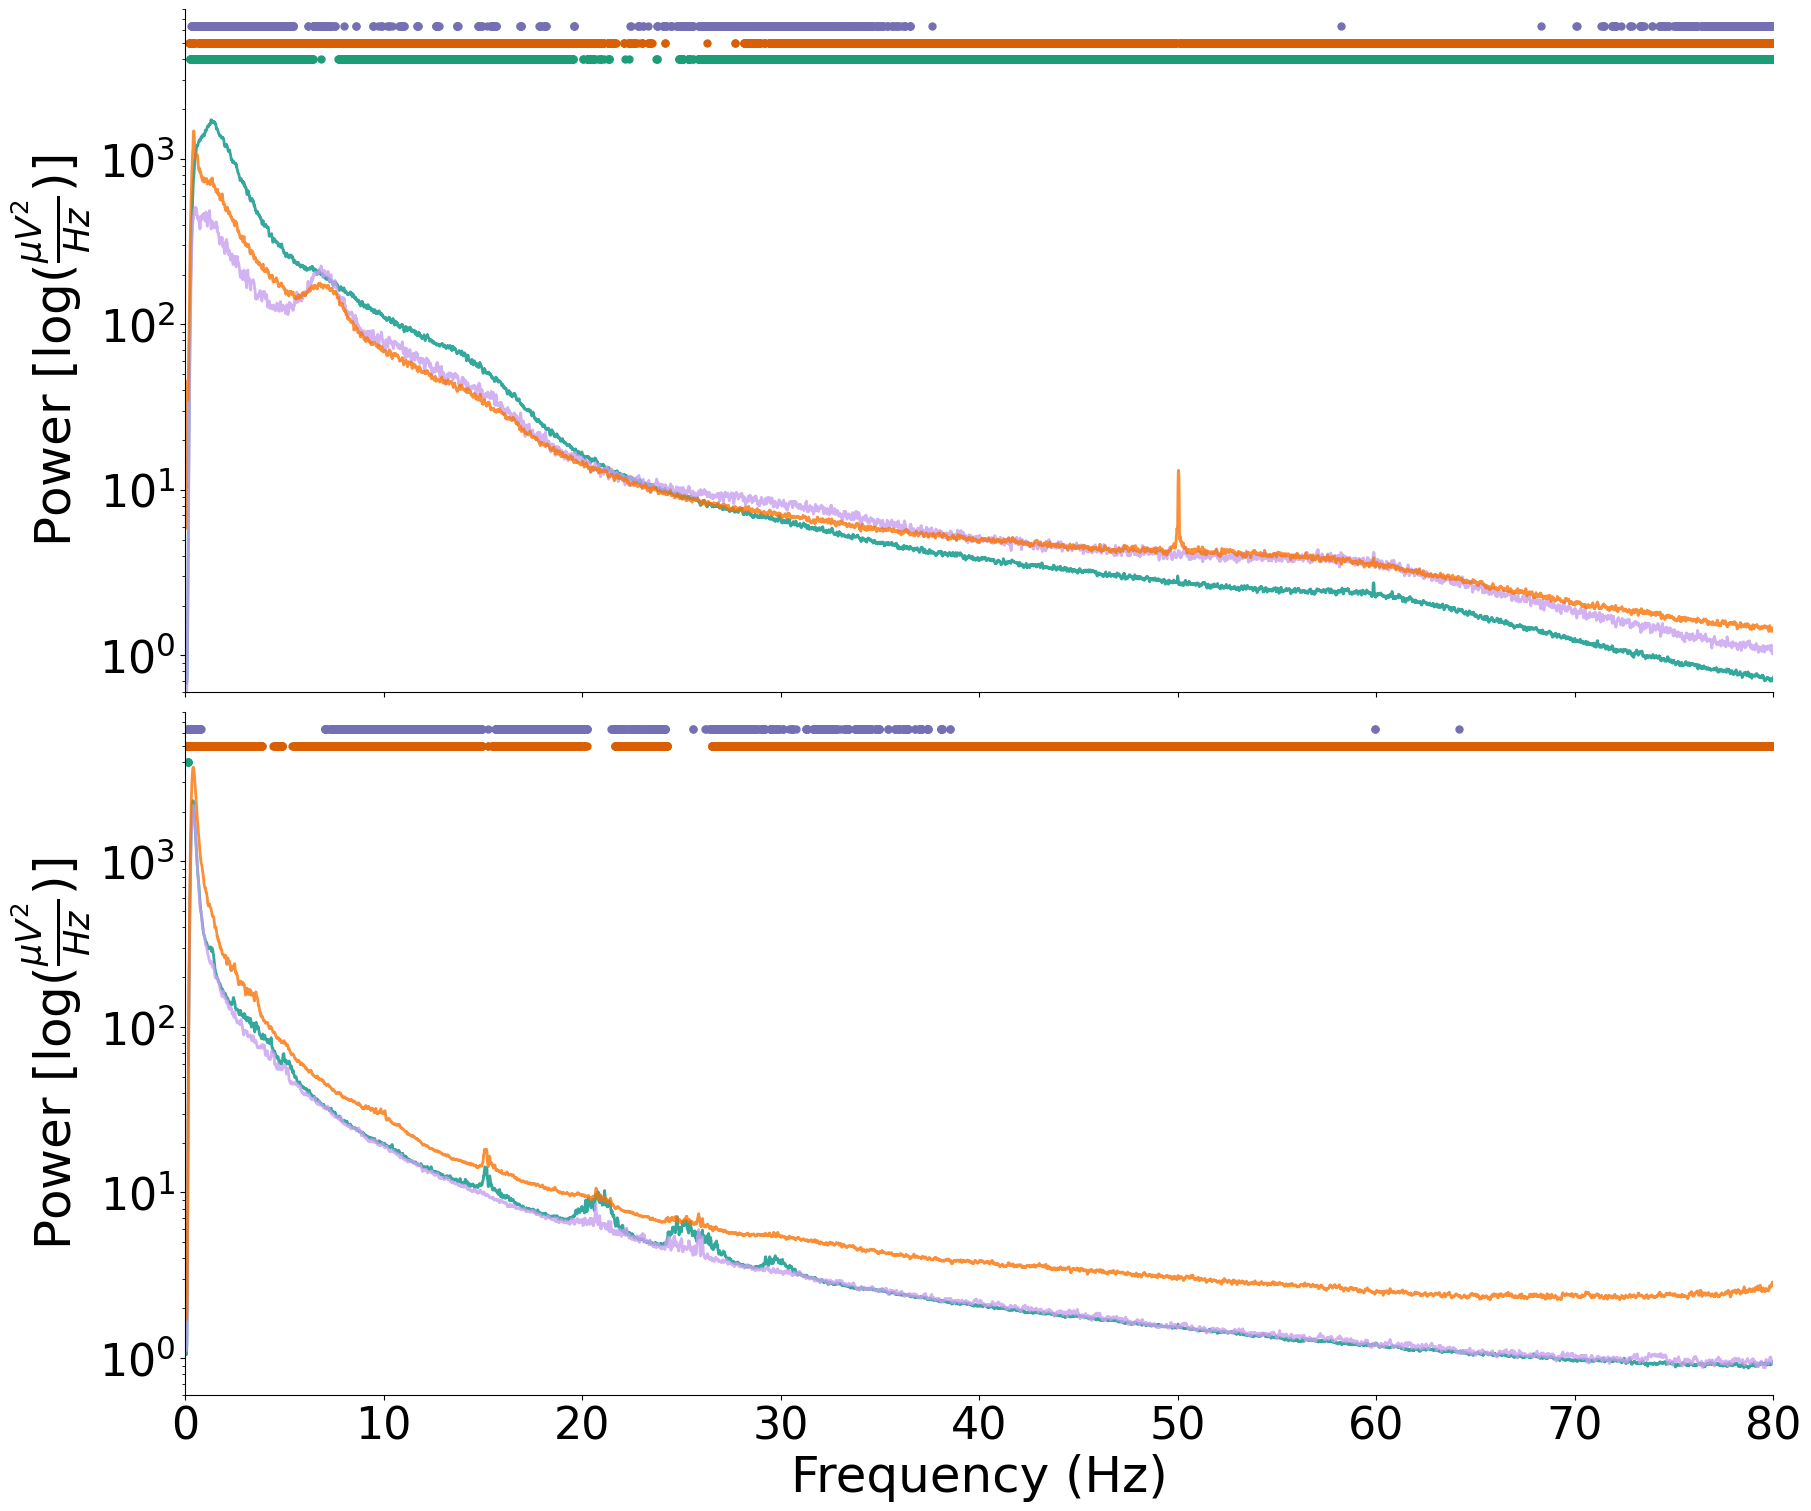

In [27]:
color_dict = {"nrem-all": "#029386", "rem-all": "#c79fef", "wake-all": "#f97306"}
fig, axs = plt.subplots(
    nrows=2, figsize=(18, 15), sharex=True, sharey=True, constrained_layout=True
)
freq_slice = slice(0, 80)
all_handles = [
    Patch(color=val["color"], label=val["label"])
    for ind, (code, val) in enumerate(new_state_code.items())
]
for ax, (region, reg_dict) in zip(axs.ravel(), region_state_dict.items()):
    # tmp_trials = trials if trigger in ["spi-peak", "so-peak"] else np.arange(28)
    ind = 0
    for state, state_data in reg_dict.items():
        state_label = state.split("-")[0]
        indices = state_data.get_index("freq").get_indexer_for(
            state_data.sel(freq=freq_slice).freq.values
        )
        # channels = ["39"] if region == "ctx" else tmp.channel.values
        # for channel in channels:
        plot_data_mean = state_data.sel(freq=freq_slice).mean(dim=("trial"))
        plot_data_std = state_data.sel(freq=freq_slice).std(dim=("trial"))
        ax.plot(
            plot_data_mean.freq.values,
            plot_data_mean,
            label=f"{state_label}",
            color=color_dict[state],
            lw=2,
            alpha=0.8,
        )
    for i in range(3):
        ax.scatter(
            state_data.freq.values[indices],
            sig_code_state_dict[region]["codes"][i, indices],
            color=new_state_code[i + 1]["color"],
            s=100,
            marker=".",
        )
        # ax.fill_between(
        #     plot_data_mean.freq.values,
        #     plot_data_mean - plot_data_std,
        #     plot_data_mean + plot_data_std,
        #     alpha=0.4,
        # )
    ax.set_ylabel("Power $[\log(\\frac{\mu V^{2}}{Hz})]$", fontsize=36)

# auto_handles, _ = axs[1].get_legend_handles_labels()
# all_handles.extend(auto_handles)
# leg = axs[1].legend(
#     handles=all_handles, handlelength=1, handleheight=0.5, ncol=2, loc="center right"
# )
# for line in leg.get_lines():
#     line.set_linewidth(3)
# ind += 1
for ax in axs.ravel():
    ax.set_yscale("log")
    ax.xaxis.set_tick_params(labelsize=32)
    ax.yaxis.set_tick_params(labelsize=32)
    ax.spines[["top", "right"]].set_visible(False)
    axs[-1].set_xlabel("Frequency (Hz)", fontsize=36)
axs[-1].set_xlabel("Frequency (Hz)", fontsize=36)
axs[-1].set_xlim([0, 80])
axs[-1].set_ylim([0.6, 8000])
fig.savefig(
    Path("/gpfs01/born/animal/DanielG/hypo_sleep/figures", "state_psd_stats.png"),
    dpi=500,
    facecolor="white",
    transparent=False,
    bbox_inches="tight",
)
# # leg = axs[-1].legend()

In [1]:
from scipy import signal

In [86]:
peaks_dict = {}
prominence = {"nrem-all": 0.5, "rem-all": 0.15, "wake-all": 0.25}
for state in ["nrem-all", "rem-all", "wake-all"]:
    peaks, _ = signal.find_peaks(
        region_state_dict["hyp"][state].mean(dim="trial").sel(freq=slice(0, 80)),
        width=8,
        prominence=prominence[state],
        distance=200,
    )
    prominences = signal.peak_prominences(
        region_state_dict["hyp"][state].mean(dim="trial").sel(freq=slice(0, 80)),
        peaks,
    )[0]
    peaks_dict[state] = {"peaks": peaks, "prominences": prominences}

In [114]:
def find_nearest(array: np.ndarray, value, tol: np.inf):
    idx = (np.abs(array - value)).argmin()
    if np.abs(array[idx] - value) < tol:
        return idx
    else:
        return

(0.0, 40.0)

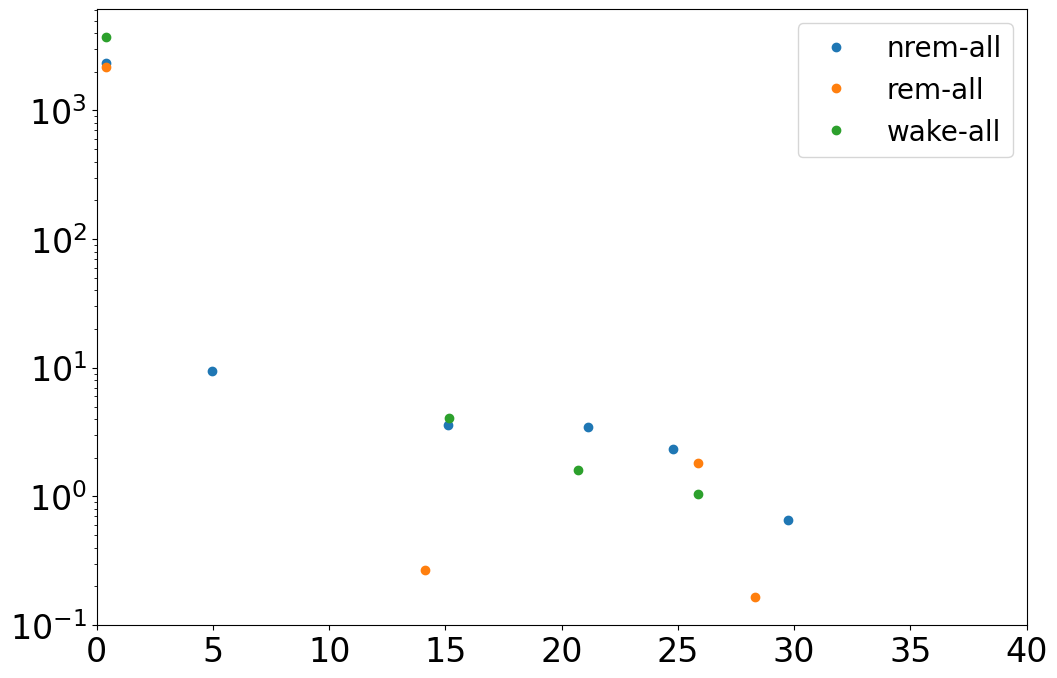

In [88]:
fig, ax = plt.subplots(figsize=(12, 8))
for state, state_peaks in peaks_dict.items():
    freqs = region_state_dict["hyp"][state].sel(freq=slice(0, 80)).freq.values
    ax.plot(freqs[state_peaks["peaks"]], state_peaks["prominences"], "o", label=state)
ax.legend()
ax.set_yscale("log")
ax.set_xlim([0, 40])